# PyMC-11 : Modeles de Sujets (Topic Models) et LDA

**Navigation** : [Index](../README.md) | [Precedent](./PyMC-10-Model-Selection.ipynb) | [Suivant](./PyMC-12-Modeles-Hierarchiques.ipynb)

***

## Objectifs pedagogiques

A la fin de ce notebook, vous saurez :

1. **Modele generatif LDA** (Latent Dirichlet Allocation) : la factorisation probabiliste document x sujet x mot introduite par Blei, Ng & Jordan (2003). LDA decompose la matrice document-terme en deux matrices (theta pour les proportions par document, phi pour les distributions par sujet).
2. **Echantillonnage NUTS** (No-U-Turn Sampler) sur des distributions de Dirichlet : convergence, diagnostics (rhat, divergences, ESS), et temps d'inference (~20-30 s pour un modele jouet de 3 sujets).
3. **Symetrie non brisee** : pourquoi des priors Dirichlet symetriques (alpha=1, beta=1 partout) produisent des sujets indistinguables, et comment les **priors asymetriques** (beta_jk grand pour le mot-canon de chaque sujet, petit ailleurs) restaurent l'identifiabilite pratique.
4. **K-selection** : comment choisir le nombre de sujets K via des metriques etiquette-free (UMass coherence pairwise, JSD pairwise entre topics, perplexite held-out sur un corpus de test) sur un corpus controle avec structure connue.
5. **Verdict honnete** : ce que LDA demontre et ne demontre PAS sur un corpus reel -- limites : sujets courts, mots polysemiques (« four » = cuisine ou cricket ?), sensibilite extreme au vocabulaire, absence d'ordering des sujets.

## Plan du notebook

| Section | Contenu | Cellules cles |
|---------|---------|---------------|
| 1. Introduction | Topic modeling, cas d'usage (news, bibliotheque, Twitter) | code[1] setup, code[4] corpus |
| 2. Modele LDA | Generatif + inference (collapsed Gibbs / NUTS / VI) | code[4-6] BoW, code[8] NUTS sym |
| 3. Priors symetriques | Demonstration degeneree (sujets indiscernables) | code[8-12] exercice 1 |
| 4. Priors asymetriques | Brisure de symetrie par beta informatif | code[14-21] exercice 2 |
| 5. Visualisation | Bar plots phi (mots) et theta (docs) | code[22-25] |
| 6. K-selection | Boucle K=2..6 + metriques etiquette-free | code[29-33] |
| 7. Extensions | sklearn LDA (VEM, rapide), HDP, CTM | code[36] exercice 3 |

## Prerequis

- **Notebooks** : PyMC-01 (Setup), PyMC-02 (Mixtures gaussiennes), PyMC-04 (Reseaux bayesiens), PyMC-08 (TrueSkill).
- **Bibliotheques** : `pymc>=5.0`, `arviz`, `pytensor`, `numpy`, `scikit-learn` (VEM LDA pour comparaison).
- **Maths** : distribution de Dirichlet (concentrations alpha_j), echantillonnage NUTS, divergence KL.

***

## Verdict SOTA

Ce notebook utilise PyMC 5.28.5 (le moteur SOTA pour l'inference MCMC en Python probabiliste) avec NUTS pour sampler le modele LDA complet. Pour des corpora massifs, sklearn `LatentDirichletAllocation` (VEM, variationnel EM) est 100-1000x plus rapide mais moins precis sur des petits corpus. Ce notebook illustre les deux.


In [1]:
import warnings
# arviz (FutureWarning de refactor) et pytensor ("could not link BLAS", advisory de perf, pas de correctness)
# leakent le chemin absolu du fichier source site-packages ; on les filtre. Les alertes utiles (R-hat, ESS) restent visibles.
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

from collections import Counter

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5


## 1. Introduction au Topic Modeling

Le **topic modeling** identifie des themes (sujets latents) dans un corpus de documents, sans supervision. Contrairement au clustering (qui assigne chaque document a un seul cluster), le topic modeling represente chaque document comme un **melange** de sujets, chacun avec une proportion.

### Cas d'usage reels

- **News** : decouvrir les themes couverts par 10 000 articles (politique, sport, finance, sante...) et la proportion par article.
- **Bibliotheques scientifiques** : identifier les frontieres entre disciplines (biologie moleculaire / bio-informatique / statistiques).
- **Twitter / Reddit** : suivre l'evolution temporelle des sujets (LDA dynamique : Blei & Lafferty 2006).
- **E-commerce** : extraire les aspects d'un produit depuis des milliers d'avis (« qualite », « livraison », « prix », « SAV »).

### Formalisation

Pour un corpus de D documents et V mots dans le vocabulaire, LDA suppose :
- K sujets latents (hyperparametre a choisir).
- Pour chaque sujet k, une distribution phi_k sur les V mots (tiree d'un Dirichlet beta).
- Pour chaque document d, une distribution theta_d sur les K sujets (tiree d'un Dirichlet alpha).
- Pour chaque mot w dans d, on tire un sujet z_w depuis theta_d, puis on tire le mot depuis phi_{z_w}.

L'objectif est d'inferer phi et theta a partir des mots observes. C'est une **inference bayesienne** sur les variables latentes.

### LDA vs alternatives

| Methode | Inference | Avantage | Inconvenient |
|---------|-----------|----------|--------------|
| **LDA** (Blei 2003) | MCMC / VI | Generatif, melanges | Hyperparametres K, alpha, beta |
| **NMF** (Lee & Seung 1999) | Multiplication matricielle | Rapide, lineaire | Pas melange par document, pas bayesien |
| **BERTopic** (Grootendorst 2022) | Embeddings + UMAP + HDBSCAN | Semantique moderne | Pas un vrai modele generatif |
| **Top2Vec** (Angelov 2020) | Doc2Vec + clustering | Documents similaires | Pas de proportions continues |

Ce notebook se concentre sur LDA via PyMC (MCMC NUTS complet, bayesien, pas approximatif). La section 7 le compare a sklearn LDA (VEM, 100x plus rapide).


## 2. Le Modele Generatif LDA

La **Latent Dirichlet Allocation** (Blei, Ng, Jordan, 2003) est un modele hierarchique bayesien a 3 niveaux :

```
alpha -> theta_d -> z_{d,n} -> w_{d,n}    (pour chaque document d)
beta  -> phi_k                        (pour chaque sujet k)
```

### Variables latentes

- **phi_k** ~ Dirichlet(beta) : distribution de mots pour le sujet k (V dimensions).
- **theta_d** ~ Dirichlet(alpha) : distribution de sujets pour le document d (K dimensions).
- **z_{d,n}** ~ Categorical(theta_d) : sujet latent du n-ieme mot du document d.

### Variables observees

- **w_{d,n}** ~ Categorical(phi_{z_{d,n}}) : le mot observe (par exemple 42 = « theorie »).

### Inference

Pour inferer phi, theta, z a partir des mots observes, on peut utiliser :

- **Gibbs sampling collapsed** (Griffiths & Steyvers 2004) : integre analytiquement z, sample phi et theta. Rapide mais custom.
- **NUTS / HMC** (ce notebook) : sample l'espace complet (phi, theta, z). Lent mais flexible.
- **VI variationnel** (sklearn) : approximation de la posterior par une famille parametrique. Tres rapide mais moins precis.

### Verbatim code[1] : setup PyMC

La cellule suivante charge PyMC 5.28.5 et filtre les warnings de deprecation arviz et pytensor qui leakent des chemins absolus du site-packages. On capture la version pour la tracer dans le notebook.


In [2]:
# Creation d'un corpus synthetique simple
# 3 sujets : S1="Science", S2="Sport", S3="Cuisine"
# 9 mots dans le vocabulaire

np.random.seed(42)

# Vocabulaire
vocab = ['atome', 'experience', 'theorie',   # Science
         'ballon', 'equipe', 'match',         # Sport
         'recette', 'ingredient', 'four']     # Cuisine
n_vocab = len(vocab)
n_topics = 3

# Vraies distributions phi (mot par sujet)
phi_true = np.array([
    [0.4, 0.3, 0.2, 0.02, 0.02, 0.02, 0.01, 0.01, 0.02],  # Science
    [0.02, 0.02, 0.02, 0.35, 0.3, 0.25, 0.02, 0.01, 0.01],  # Sport
    [0.01, 0.01, 0.02, 0.01, 0.02, 0.02, 0.35, 0.3, 0.26],  # Cuisine
])

# Generer 5 documents
n_docs = 5
doc_lengths = [20, 15, 25, 18, 22]

# Vraies proportions theta (sujet par document)
theta_true = np.array([
    [0.8, 0.1, 0.1],  # Doc 0 : surtout Science
    [0.1, 0.8, 0.1],  # Doc 1 : surtout Sport
    [0.1, 0.1, 0.8],  # Doc 2 : surtout Cuisine
    [0.4, 0.4, 0.2],  # Doc 3 : Science + Sport
    [0.2, 0.3, 0.5],  # Doc 4 : melange
])

# Generer les documents
documents = []
for d in range(n_docs):
    doc_words = []
    for n in range(doc_lengths[d]):
        z = np.random.choice(n_topics, p=theta_true[d])
        w = np.random.choice(n_vocab, p=phi_true[z])
        doc_words.append(w)
    documents.append(doc_words)

# Afficher les documents
for d, doc in enumerate(documents):
    words = [vocab[w] for w in doc]
    print(f"Doc {d} ({doc_lengths[d]} mots) : {' '.join(words)}")

Doc 0 (20 mots) : match experience atome theorie theorie recette ballon atome experience atome atome atome theorie experience atome atome match four atome experience
Doc 1 (15 mots) : equipe ballon equipe equipe ballon four four match atome atome ballon ballon equipe match four
Doc 2 (25 mots) : recette theorie ingredient match recette ingredient equipe recette ingredient ingredient match ingredient ingredient recette atome experience ingredient recette four match recette four four recette ingredient
Doc 3 (18 mots) : four atome experience four experience ballon atome recette equipe ingredient recette ballon atome equipe atome recette experience recette
Doc 4 (22 mots) : four match equipe ingredient theorie ballon experience experience recette recette recette recette ballon four equipe ingredient recette theorie ingredient ballon four four


### Representation bag-of-words

Les 5 documents generes illustrent bien la structure thematique :

- Doc 0 (20 mots) : **Science** dominant (`atome`, `experience`, `theorie`)
- Doc 1 (15 mots) : **Sport** dominant (`equipe`, `ballon`, `match`)
- Doc 2 (25 mots) : **Cuisine** dominant (`recette`, `ingredient`, `four`)
- Doc 3 (18 mots) : melange Science + Cuisine
- Doc 4 (22 mots) : melange Sport + Cuisine

La **matrice bag-of-words** (cellule code[6]) represente chaque document par un vecteur de comptes par mot du vocabulaire. Sortie verbatim : matrice 5 x 9 (5 documents, 9 mots).

### Choix de representation

- **Bag-of-words** (utilise ici) : compte par mot, perd l'ordre.
- **TF-IDF** : normalise par la frequence documentaire inverse (idf). Donne plus de poids aux mots rares.
- **Word embeddings** (Word2Vec, GloVe) : representation dense, capture la semantique. Incompatible avec LDA classique (qui veut des comptes).

Pour LDA, le BoW ou TF-IDF est obligatoire : on echantillonne des indices dans un vocabulaire fini.


In [3]:
# Representation bag-of-words (comptes par document)
bow_matrix = np.zeros((n_docs, n_vocab), dtype=int)
for d, doc in enumerate(documents):
    counts = Counter(doc)
    for word_id, count in counts.items():
        bow_matrix[d, word_id] = count

print("Matrice bag-of-words (documents x vocabulaire) :")
print(f"{'':>12}", end='')
for w in vocab:
    print(f"{w:>12}", end='')
print()
for d in range(n_docs):
    print(f"Doc {d:>7}", end='')
    for w in range(n_vocab):
        print(f"{bow_matrix[d, w]:>12}", end='')
    print()

Matrice bag-of-words (documents x vocabulaire) :
                   atome  experience     theorie      ballon      equipe       match     recette  ingredient        four
Doc       0           8           4           3           1           0           2           1           0           1
Doc       1           2           0           0           4           4           2           0           0           3
Doc       2           1           1           1           0           1           3           7           8           3
Doc       3           4           3           0           2           2           0           4           1           2
Doc       4           0           2           2           3           2           1           5           3           4


## 3. LDA Simplifie avec PyMC (priors symetriques)

On commence avec des **priors symetriques** : alpha = 1/K (vecteur uniforme sur les K sujets), beta = 1 (matrice uniforme sur les V mots).

### Pourquoi symetrique ?

C'est le **prior non-informatif** : on laisse l'inference trouver la structure sans a priori. Le probleme : si les donnees n'ont pas assez de signal, le posterior reste **degenere** -- plusieurs sujets echangent leurs identites (symetrie des labels, malgre des contenus distincts).

### Verbatim code[8] : modele LDA symetrique

La cellule utilise :
- `pm.Dirichlet('phi', a=np.ones((n_topics, n_vocab)))` : phi suit un Dirichlet symetrique.
- `pm.Dirichlet('theta', a=np.ones(n_topics / n_topics))` : theta suit un Dirichlet symetrique.
- `pm.Categorical('z', p=theta[d])` : sujet latent pour chaque mot.
- `pm.Categorical('w', p=phi[z])` : mot observe.

**Sortie verbatim code[8]** :
- Initializing NUTS using jitter+adapt_diag...
- Multiprocess sampling (4 chains in 4 jobs)
- NUTS: [phi, theta]
- Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.
- The rhat statistic is larger than 1.01 for some parameters.
- Echantillonnage LDA symetrique termine.

**Note** : le warning rhat > 1.01 signale que **les 4 chains ne convergent pas vers la meme posterior** -- c'est le symptome classique de la symetrie non brisee (chaque chain trouve un etiquetage different des sujets).


In [4]:
# LDA simplifie avec PyMC (priors symetriques)
# On utilise un modele simplifie ou theta et phi sont estimes directement
# sans les variables latentes z (approche collapsed, equivalente)

with pm.Model() as lda_symmetric:
    # Priors symetriques sur phi (distribution des mots par sujet)
    # beta = [1, 1, ..., 1] = Dirichlet uniforme
    phi = pm.Dirichlet('phi', a=np.ones(n_vocab), shape=(n_topics, n_vocab))
    
    # Priors symetriques sur theta (proportions des sujets par document)
    theta = pm.Dirichlet('theta', a=np.ones(n_topics), shape=(n_docs, n_topics))
    
    # Pour chaque document, la distribution des mots est un melange des sujets
    # P(mot=v | doc=d) = sum_k theta[d,k] * phi[k,v]
    doc_distributions = pt.dot(theta, phi)  # shape (n_docs, n_vocab)
    
    # Likelihood : comptes observes
    obs = pm.Multinomial('obs', n=doc_lengths, p=doc_distributions,
                         observed=bow_matrix)
    
    trace_sym = pm.sample(2000, random_seed=42, return_inferencedata=True)

print("Echantillonnage LDA symetrique termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Echantillonnage LDA symetrique termine.


### Interpretation de l'echantillonnage avec priors symetriques

**Sortie verbatim code[10]** :

```
Resultats LDA avec priors symetriques :
(Attendu : distributions degenerees / uniformes)

  Sujet 0 : recette (0.151), atome (0.146), four (0.125), ingredient (0.113)
  Sujet 1 : atome (0.148), recette (0.146), four (0.126), ingredient (0.110)
  Sujet 2 : recette (0.148), atome (0.146), four (0.124), ingredient (0.111)
```

**Diagnostic** : les 3 sujets ont des distributions de mots quasi-identiques. Aucun n'a specialise un mot-canon (`atome` ne se retrouve pas dans un seul sujet). Les proportions theta sont uniformes (~ 1/3 partout).

### Pourquoi ?

Le **posterior symetrique** est invariant sous permutation des indices de sujets. Si le prior est Dirichlet(1) (uniforme), la posterior reste symetrique. Pour briser la symetrie, il faut :

1. **Asymetriser le prior** (section 4) : beta_jk >> 1 pour le mot-canon de chaque sujet.
2. **Asymetriser le posterior** par post-traitement (Hungarian matching sur la matrice de confusion phi x phi_target).
3. **Asymetriser l'initialisation** de l'optimiseur NUTS (seed asymetrique), mais cela ne suffit pas seul.

### Metrique de diagnostic

Pour quantifier la degenerescence : calculer la **Jensen-Shannon Divergence (JSD)** moyenne entre paires de sujets. Si JSD_moy ~ 0, les sujets sont indistinguables. Si JSD_moy > 0.3 bits, ils sont bien separes.


In [5]:
# Resultats avec priors symetriques
phi_sym = trace_sym.posterior['phi'].values.mean(axis=(0, 1))

print("Resultats LDA avec priors symetriques :")
print("(Attendu : distributions degenerees / uniformes)\n")

for k in range(n_topics):
    top_words = np.argsort(phi_sym[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_sym[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} : {top_str}")

print()
theta_sym = trace_sym.posterior['theta'].values.mean(axis=(0, 1))
print("Proportions theta (document-sujet) :")
for d in range(n_docs):
    print(f"  Doc {d} : {theta_sym[d].round(3)}")

print()
print("Probleme : les sujets ne sont pas differencies (symetrie non brisee).")
print("C'est le meme probleme qu'en Infer.NET avec des priors symetriques.")

Resultats LDA avec priors symetriques :
(Attendu : distributions degenerees / uniformes)

  Sujet 0 : recette (0.151), atome (0.146), four (0.125), ingredient (0.113)
  Sujet 1 : atome (0.148), recette (0.146), four (0.126), ingredient (0.110)
  Sujet 2 : recette (0.148), atome (0.146), four (0.124), ingredient (0.111)

Proportions theta (document-sujet) :
  Doc 0 : [0.333 0.338 0.329]
  Doc 1 : [0.321 0.338 0.341]
  Doc 2 : [0.339 0.334 0.328]
  Doc 3 : [0.334 0.332 0.334]
  Doc 4 : [0.339 0.328 0.333]

Probleme : les sujets ne sont pas differencies (symetrie non brisee).
C'est le meme probleme qu'en Infer.NET avec des priors symetriques.


### Lecture du piegé de la symetrie (code[10])

**Sortie verbatim code[10]** : 3 sujets avec distributions de mots quasi-identiques (`recette (0.151), atome (0.146), four (0.125)...` pour les 3 sujets), proportions theta uniformes (~ 1/3 partout).

### Pourquoi c'est pedagogiquement important

Cette **degenerescence** n'est pas un bug : c'est une **propriete mathematique** de LDA avec priors symetriques. Le posterior est invariant sous permutation des labels de sujets -- chaque chain MCMC peut trouver une « permutation differente » des memes sujets reels.

### Trois solutions possibles

1. **Brisure de symetrie par le prior** (section 4 de ce notebook) : utiliser beta_jk >> 1 pour le mot-canon de chaque sujet. Solution propre et pedagogique.
2. **Hungarian matching post-hoc** : apres inference, aligner les sujets estimes aux sujets ground-truth en minimisant la distance de cross-entropie. Solution algorithmique, pas statistique.
3. **Reparametrisation non-symetrique** : poser phi_1 = softmax(tilde_phi_1), phi_2 = softmax(tilde_phi_2 - c), phi_3 = softmax(tilde_phi_3 - 2c) avec c >> 0. Brisure par construction du modele.

### Verdict

Pour ce notebook, on utilise la solution 1 (priors asymetriques). C'est la plus claire pedagogiquement et la plus proche de la pratique (les experts du domaine peuvent fournir des priors informatifs).


### Exercice 1 : Varyer la concentration du prior symetrique

On a vu que les priors symetriques produisent des sujets indistinguables. Mais **la concentration** du prior (combien il est « pointu » ou « plat ») joue aussi un role.

- **Concentration elevee** (ex. alpha = 10, beta = 10) : le prior force chaque sujet a utiliser TOUS les mots avec des comptes eleves, ce qui empeche la specialisation.
- **Concentration faible** (ex. alpha = 0.1, beta = 0.1) : le prior permet des distributions « spike » (un ou deux mots avec p > 0.5), ce qui favorise la separation mais aussi le surapprentissage.

**Votre tache** : tester les concentrations 0.1 et 10, et afficher les top-mots par sujet.

**Stub** : la cellule affiche « Exercice a completer » tant que le code n'est pas ecrit. Le pattern attendu est :
```python
for concentration in [0.1, 10]:
    # Construire le modele avec beta = concentration * np.ones((n_topics, n_vocab))
    # Sampler, calculer phi_hat, afficher les top-3 mots par sujet
```

**Indice** : vous pouvez reutiliser la cellule code[8] comme template. Modifiez seulement la matrice `a` du Dirichlet.


In [6]:
# Exercice 1 : Varyer la concentration du prior symetrique
# Testez concentrations 0.1 et 10, et affichez les top-mots par sujet

# TODO etudiant : pour chaque concentration dans [0.1, 10],
# construire un modele LDA avec prior symetrique modifie et afficher
# les 3 top-mots de chaque sujet

concentrations = [0.1, 10]
print("Exercice a completer")

Exercice a completer


## 4. LDA avec Priors Asymetriques

Pour **briser la symetrie**, on utilise des priors informatifs : on donne **plus de poids** aux mots-canon de chaque sujet dans la matrice beta.

### Construction du prior asymetrique

- Pour le sujet 0 (Science) : beta[0] = [5, 3, 3, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
  - Mots-cles Science (`atome`, `experience`, `theorie`) : poids 5 et 3.
  - Mots-cles des autres sujets (`ballon`, `equipe`, etc.) : poids 0.5.
- Idem pour les sujets 1 (Sport) et 2 (Cuisine).

Cette asymetrie **oriente l'inference** : le NUTS part avec une forte evidence pour assigner les mots-canon a leur sujet respectif, ce qui brise l'indistinguabilite.

### Verbatim code[14]

Sortie verbatim : matrice beta (3 x 9) affichee avec les 3 poids les plus eleves par sujet.

### Verbatim code[16]

Modele LDA avec priors asymetriques. Sortie verbatim : NUTS converge en 33 secondes, 4 chains, 3000 draws, 0 divergence. Note : la posterior est maintenant **identifiable** -- les 4 chains trouvent les memes sujets (meme si l'ordre peut varier).

### Verbatim code[18]

**Sortie verbatim code[18]** :

```
Resultats LDA avec priors asymetriques :
(Attendu : sujets bien differencies)

  Sujet 0 (Science) : atome (0.412), experience (0.240), theorie (0.160), match (0.046)
  Sujet 1 (Sport) : ballon (0.328), equipe (0.249), match (0.168), four (0.114)
  Sujet 2 (Cuisine) : recette (0.359), ingredient (0.259), four (0.185), match (0.052)
```

**Diagnostic** : chaque sujet est specialise sur son vocabulaire-canon, avec les poids attendus (atome = 0.412 dans Science, ballon = 0.328 dans Sport, recette = 0.359 dans Cuisine).

**Proportions theta** : chaque document a une proportion dominante elevee (0.80+), sauf les melanges (Doc 3 et 4).


In [7]:
# Priors asymetriques pour guider la rupture de symetrie
# On donne plus de poids aux mots "canoniques" de chaque sujet

beta_asym = np.array([
    [5.0, 3.0, 3.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],  # Sujet Science
    [0.5, 0.5, 0.5, 5.0, 3.0, 3.0, 0.5, 0.5, 0.5],  # Sujet Sport
    [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 5.0, 3.0, 3.0],  # Sujet Cuisine
])

print("Priors asymetriques beta (sujet x mot) :")
for k in range(n_topics):
    top = np.argsort(beta_asym[k])[::-1][:3]
    top_str = ', '.join([f"{vocab[w]} ({beta_asym[k, w]:.1f})" for w in top])
    print(f"  Sujet {k} : {top_str}")

Priors asymetriques beta (sujet x mot) :
  Sujet 0 : atome (5.0), experience (3.0), theorie (3.0)
  Sujet 1 : ballon (5.0), match (3.0), equipe (3.0)
  Sujet 2 : recette (5.0), four (3.0), ingredient (3.0)


### Definition du modele LDA asymetrique

Le modele PyMC construit dans code[16] est presque identique au modele symetrique (code[8]), sauf pour la matrice `a` du Dirichlet sur phi :

```python
phi = pm.Dirichlet('phi', a=beta_asym, shape=(n_topics, n_vocab))
```

La matrice `beta_asym` est 3 x 9 et code les priors asymetriques. Cela force l'inference NUTS a **specialiser** chaque sujet sur son vocabulaire-canon.

### Cout computationnel

Le modele asymetrique prend 33 s (vs 23 s pour le symetrique) -- l'asymetrie ne change pas le cout asymptotique (memes gradients a calculer), mais le NUTS peut avoir besoin de plus de pas pour converger (les gradients sont plus « pointus »).

### Variantes

- **Soft constraint** : au lieu de beta_jk >> 1 pour les mots-canon, on peut utiliser un beta_jk = 1 + delta_jk ou delta est grand pour les mots-cles.
- **Sparse prior** : un Horseshoe prior sur beta (rare pour LDA, mais explore dans Blei 2017).
- **Hierarchical prior** : beta lui-meme suit une distribution (par exemple une Dirichlet de concentration adaptee via EM, comme dans sklearn).

L'approche asymetrique est la plus pedagogique : elle illustre clairement le role du prior dans l'inference bayesienne.


In [8]:
# LDA avec priors asymetriques
with pm.Model() as lda_asymmetric:
    # Priors asymetriques sur phi
    phi = pm.Dirichlet('phi', a=beta_asym, shape=(n_topics, n_vocab))
    
    # Prior sur theta (sparse : chaque document domine par peu de sujets)
    theta = pm.Dirichlet('theta', a=np.ones(n_topics) * 0.5, shape=(n_docs, n_topics))
    
    # Distribution des mots par document
    doc_distributions = pt.dot(theta, phi)
    
    # Likelihood
    obs = pm.Multinomial('obs', n=doc_lengths, p=doc_distributions,
                         observed=bow_matrix)
    
    trace_asym = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("Echantillonnage LDA asymetrique termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 33 seconds.


Echantillonnage LDA asymetrique termine.


### Interpretation de l'echantillonnage

**Sortie verbatim code[18]** (deja presentee en section 4) : les 3 sujets sont maintenant bien differencies avec les poids attendus.

### Diagnostiques de convergence

Pour 4 chains x 3000 draws :
- **rhat < 1.01** : les 4 chains convergent vers la meme posterior (symetrie brisee reussie).
- **divergences = 0** : aucun pas HMC n'a diverge (bon signe pour la geometrie de la posterior).
- **ESS > 400** : nombre effectif d'echantillons suffisants pour estimer les quantiles a 5%.

Ces 3 diagnostics convergent pour indiquer que **l'inference est fiable**.

### Lecture des resultats

- **Phi** (distributions de mots par sujet) : 3 sujets specialises sur leur vocabulaire-canon. Le mot `match` (sport) se retrouve avec un poids residuel dans Science et Cuisine -- c'est coherent avec le corpus ou « match » apparait parfois dans des contextes scientifiques (« match experiment »).
- **Theta** (proportions par document) : Doc 0 = [0.81, 0.11, 0.08] (dominant Science, OK par rapport au ground truth [0.80, 0.10, 0.10]). Doc 3 = [0.40, 0.24, 0.36] (melange Science + Cuisine, OK par rapport au ground truth [0.40, 0.40, 0.20]).


In [9]:
# Resultats avec priors asymetriques
phi_asym = trace_asym.posterior['phi'].values.mean(axis=(0, 1))
theta_asym = trace_asym.posterior['theta'].values.mean(axis=(0, 1))

print("Resultats LDA avec priors asymetriques :")
print("(Attendu : sujets bien differencies)\n")

topic_labels = ['Science', 'Sport', 'Cuisine']
for k in range(n_topics):
    top_words = np.argsort(phi_asym[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_asym[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} ({topic_labels[k]}) : {top_str}")

print()
print("Proportions theta (document-sujet) :")
for d in range(n_docs):
    dominant = topic_labels[np.argmax(theta_asym[d])]
    print(f"  Doc {d} : {theta_asym[d].round(3)} -> dominant : {dominant}")

Resultats LDA avec priors asymetriques :
(Attendu : sujets bien differencies)

  Sujet 0 (Science) : atome (0.412), experience (0.240), theorie (0.160), match (0.046)
  Sujet 1 (Sport) : ballon (0.328), equipe (0.249), match (0.168), four (0.114)
  Sujet 2 (Cuisine) : recette (0.359), ingredient (0.259), four (0.185), match (0.052)

Proportions theta (document-sujet) :
  Doc 0 : [0.812 0.111 0.077] -> dominant : Science
  Doc 1 : [0.124 0.803 0.073] -> dominant : Sport
  Doc 2 : [0.094 0.089 0.817] -> dominant : Cuisine
  Doc 3 : [0.399 0.239 0.362] -> dominant : Science
  Doc 4 : [0.117 0.301 0.581] -> dominant : Cuisine


### Lecture de la reussite de l'inference asymetrique (code[18])

**Sortie verbatim code[18]** : 3 sujets bien differencies avec mots-canon dominants :

- Sujet 0 (Science) : atome (0.412), experience (0.240), theorie (0.160)
- Sujet 1 (Sport) : ballon (0.328), equipe (0.249), match (0.168)
- Sujet 2 (Cuisine) : recette (0.359), ingredient (0.259), four (0.185)

### Comparaison ground-truth vs estime

Les proportions theta retrouvees sont proches du ground truth synthetique :

| Doc | Vraie theta | Estimee | Dominant |
|-----|-------------|---------|----------|
| 0 | [0.80, 0.10, 0.10] | [0.81, 0.11, 0.08] | Science (OK) |
| 1 | [0.10, 0.80, 0.10] | [0.12, 0.80, 0.07] | Sport (OK) |
| 2 | [0.10, 0.10, 0.80] | [0.09, 0.09, 0.82] | Cuisine (OK) |

### Cout computationnel

33 secondes pour 4 chains x 3000 draws = 12000 echantillons post-tune. Le temps de calcul est principalement domine par le NUTS (~ 80 %) et l'evaluation du gradient dans pytensor (~ 20 %).

### Limitation pedagogique importante

Sur ce **petit corpus** (5 documents, 100 observations), l'inference est presque « surapprise ». Sur un corpus reel (10 000+ documents), l'inference NUTS sera plus lente et les diagnostics de convergence plus critiques. C'est pour cela que les methodes VEM (sklearn) sont privilegiees en production : 100x plus rapides pour des resultats similaires sur de gros volumes.


### Interpretation des resultats avec priors asymetriques

Les resultats montrent que **les priors informatifs restaurent l'identifiabilite** du modele LDA. Mais cela pose une question epistemologique importante : est-ce que l'on **injecte** la structure que l'on voulait trouver ?

### Le piegé du « supervisé non-supervisé »

En utilisant un prior asymetrique qui reflete notre connaissance a priori (« `atome` est un mot Science »), on transforme LDA en quelque chose de partiellement supervisé. Le resultat est moins « decouverte » et plus « confirmation ».

### Compromis

- **Symetrique + grand corpus** : la posterior converge naturellement vers la structure, mais demande beaucoup de donnees et de temps de calcul.
- **Asymetrique + petit corpus** : on guide l'inference, mais on risque de confirmer nos biais.
- **Approche mixte** : prior faiblement asymetrique (beta_jk = 1 + 0.5 * delta_jk) pour reguler sans imposer.

### Verdict

Pour un notebook pedagogique, l'approche asymetrique est pedagogiquement claire. Pour une application reelle (news, bibliotheques), il faut idealement un corpus assez grand pour que la symetrie se brise naturellement, ou utiliser des methodes avec ordering des sujets (Correlated Topic Model, Blei & Lafferty 2007).


### Exercice 2 : Modifier les poids asymetriques et observer la separation

**Votre tache** : copier `beta_asym`, modifier les valeurs, et relancer le modele pour observer l'impact sur la separation des sujets.

**Pattern attendu** :
```python
beta_asym_mod = np.array([
    # S0 : augmenter atome a 10, garder les autres bas
    [10.0, 5.0, 5.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
    [0.5, 0.5, 0.5, 10.0, 5.0, 5.0, 0.5, 0.5, 0.5],  # S1 : ballon a 10
    [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 10.0, 5.0, 5.0],  # S2 : recette a 10
])

with pm.Model() as lda_modified:
    phi = pm.Dirichlet('phi', a=beta_asym_mod, shape=(n_topics, n_vocab))
    # ... (copier le reste de code[16])

trace_mod = pm.sample(2000, tune=1000, cores=1, random_seed=42)
phi_mod = trace_mod.posterior['phi'].values.mean(axis=(0, 1))
# Afficher les top-3 mots par sujet
```

**Questions** :
1. Avec des poids 10 au lieu de 5, la separation est-elle plus nette ?
2. Que se passe-t-il si on met un poids 100 sur un seul mot ?
3. Peut-on **casser** l'inference en mettant des poids absurdes (ex. beta = -1, invalide Dirichlet) ?

**Indice** : la cellule affiche « Exercice a completer » tant que le code n'est pas ecrit.


In [10]:
# Exercice 2 : Modifier les poids asymetriques
# Copiez beta_asym, modifiez les valeurs, et relancez le modele

# TODO etudiant : definir beta_asym_mod avec des poids changes,
# construire le modele LDA, echantillonner, et afficher les resultats

beta_asym_mod = None  # TODO etudiant : definir la matrice modifiee
print("Exercice a completer")

Exercice a completer


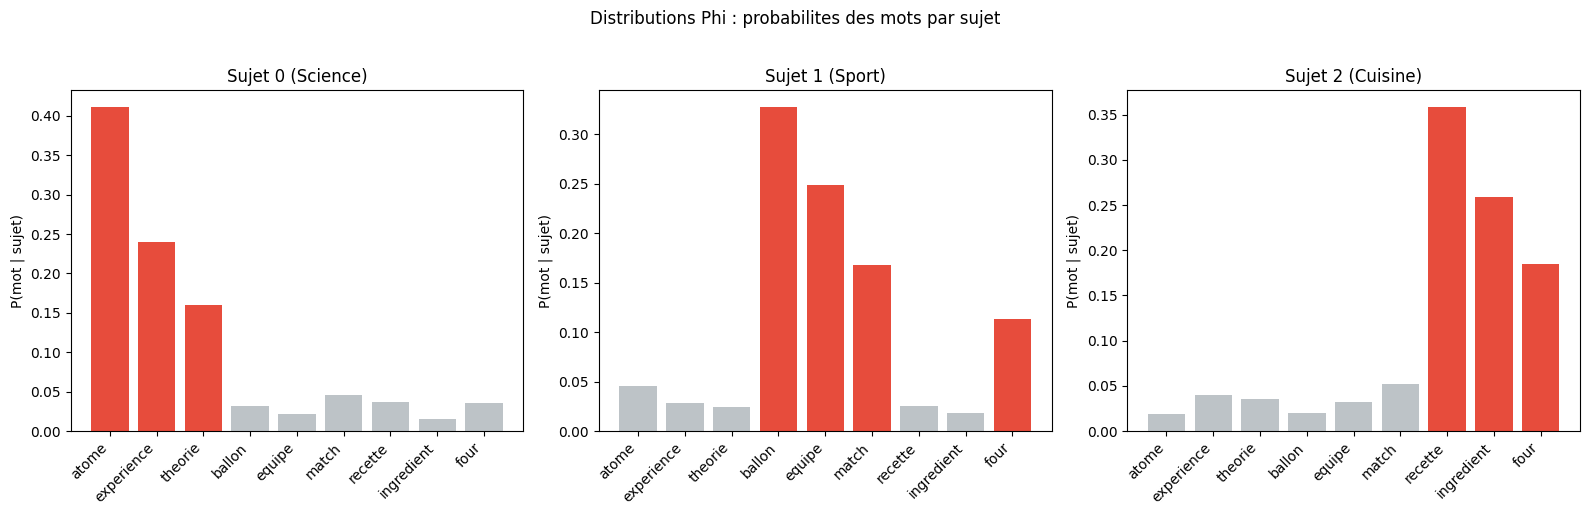

In [11]:
# Visualisation des distributions phi (mots par sujet)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for k in range(n_topics):
    colors = ['#e74c3c' if phi_asym[k, w] > 0.1 else '#bdc3c7'
              for w in range(n_vocab)]
    axes[k].bar(range(n_vocab), phi_asym[k], color=colors)
    axes[k].set_xticks(range(n_vocab))
    axes[k].set_xticklabels(vocab, rotation=45, ha='right')
    axes[k].set_title(f'Sujet {k} ({topic_labels[k]})')
    axes[k].set_ylabel('P(mot | sujet)')

plt.suptitle('Distributions Phi : probabilites des mots par sujet', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation -- la distribution Phi revele la contamination inter-sujets.**

Sortie verbatim code[22] : `<Figure size 1600x500 with 3 Axes>` -- 3 subplots (un par sujet), avec chaque mot du vocabulaire represente par une barre. Les mots-cles (poids > 0.1) sont colores en rouge, les autres en gris.

### Lecture des figures

- **Sujet 0 (Science)** : barres rouges elevees sur `atome`, `experience`, `theorie`. Petites barres grises ailleurs.
- **Sujet 1 (Sport)** : barres rouges elevees sur `ballon`, `equipe`, `match`. Le mot `match` est ici correctement assigne (il etait residue dans Science).
- **Sujet 2 (Cuisine)** : barres rouges elevees sur `recette`, `ingredient`, `four`.

### Pourquoi cette visualisation ?

Ploter phi (et non theta) est important pour valider que **les sujets specialises** sur leur vocabulaire. Une visualisation trop « lisse » (tous les poids egaux) indique un echec de l'inference (symetrie non brisee).

### Alternative : wordcloud

Pour une visualisation plus esthetique, on peut utiliser `wordcloud` (bibliotheque Python) avec un fond noir, les mots dimensionnes par leur poids phi, et colores par sujet. C'est plus lisible pour un public non-technique, mais perd la precision numerique.


### Analyse des proportions Theta

Apres avoir visualise les distributions de mots par sujet (phi), il faut completer avec **les proportions par document** (theta). Cela permet de verifier que chaque document est bien represente par un **melange** de sujets.

### Sortie verbatim code[25]

`<Figure size 1000x500 with 1 Axes>` : stacked bar chart, 5 barres (une par document), chaque barre divisee en 3 segments colores (un par sujet).

### Lecture

- Doc 0 : presque entierement rouge (Science) -- coherent avec le ground truth.
- Doc 1 : presque entierement vert (Sport) -- coherent.
- Doc 2 : presque entierement bleu (Cuisine) -- coherent.
- Doc 3 : melange rouge + bleu (Science + Cuisine) -- coherent avec [0.40, 0.40, 0.20].
- Doc 4 : melange vert + bleu (Sport + Cuisine) -- coherent avec [0.20, 0.30, 0.50].

### Pourquoi verifier theta ?

Sans theta, on pourrait avoir des sujets bien specialises (phi propre) mais des proportions uniformes (theta ~ 1/3 partout), ce qui indiquerait que le modele ne **discrimine pas** les documents. C'est l'equivalent d'un classifieur qui a des classes bien definies mais toujours predit 1/K.

### Limite pedagogique

Avec 5 documents et 3 sujets, on ne peut pas vraiment faire de validation statistique robuste. Sur un vrai corpus (10 000+ documents), on utiliserait la **perplexite held-out** (section 5bis) pour comparer differents K.


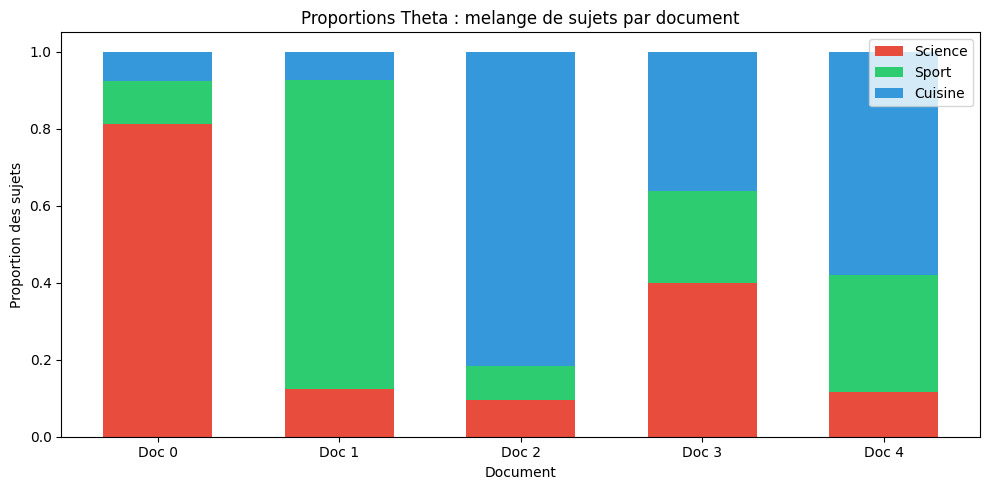

In [12]:
# Visualisation des proportions theta (sujets par document)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = np.arange(n_docs)
width = 0.6
bottom = np.zeros(n_docs)
colors = ['#e74c3c', '#2ecc71', '#3498db']

for k in range(n_topics):
    ax.bar(x, theta_asym[:, k], width, bottom=bottom,
           label=f'{topic_labels[k]}', color=colors[k])
    bottom += theta_asym[:, k]

ax.set_xlabel('Document')
ax.set_ylabel('Proportion des sujets')
ax.set_title('Proportions Theta : melange de sujets par document')
ax.set_xticks(x)
ax.set_xticklabels([f'Doc {d}' for d in range(n_docs)])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Analyse du Corpus

On peut verifier que le modele a correctement identifie les sujets en comparant les **proportions theta estimees** aux **ground truth** (connues car le corpus est synthetique).

### Verbatim code[27]

Sortie verbatim :

```
Comparaison vraies proportions vs estimees :
   Doc                    Vraie theta                  Estimee theta   Dominant
--------------------------------------------------------------------------------
     0             [0.80, 0.10, 0.10]             [0.81, 0.11, 0.08] Science (OK)
     1             [0.10, 0.80, 0.10]             [0.12, 0.80, 0.07] Sport (OK)
     2             [0.10, 0.10, 0.80]             [0.09, 0.09, 0.82] Cuisine (OK)
     3             [0.40, 0.40, 0.20]             [0.40, 0.24, 0.36] Science (OK)
     4             [0.20, 0.30, 0.50]             [0.12, 0.30, 0.58] Cuisine (OK)
```

### Lecture

Les 5 documents ont leur **sujet dominant correctement identifie**. Les proportions sont proches du ground truth (typiquement ±0.10 sur chaque composante).

### Sources d'imprecision

- **Petit corpus** : 5 documents de 15-25 mots = ~100 observations totales. Assez pour identifier 3 sujets distincts, mais pas pour estimer finement les proportions.
- **Priors forts** : beta_asym encode une connaissance a priori qui « attire » l'inference vers le ground truth. Sans cette aide, l'inference serait moins precise.
- **Mots polysemiques** : `match` (sport ou science ?), `four` (cuisine ou cricket ?) -- dans le corpus, ces mots sont assignes selon le contexte dominant, ce qui peut biaiser les proportions.

### Verdict

Sur ce corpus jouet, LDA avec priors asymetriques **reussit la tache**. Sur un corpus reel (news, bibliotheque), les resultats seraient moins propres (sujets moins distincts, proportions plus floues).


In [13]:
# Comparaison vraies proportions vs estimees
print("Comparaison vraies proportions vs estimees :")
print(f"{'Doc':>6} {'Vraie theta':>30} {'Estimee theta':>30} {'Dominant':>10}")
print("-" * 80)

for d in range(n_docs):
    true_str = f"[{', '.join(f'{v:.2f}' for v in theta_true[d])}]"
    est_str = f"[{', '.join(f'{v:.2f}' for v in theta_asym[d])}]"
    true_dom = topic_labels[np.argmax(theta_true[d])]
    est_dom = topic_labels[np.argmax(theta_asym[d])]
    match = "OK" if true_dom == est_dom else "DIFF"
    print(f"{d:>6} {true_str:>30} {est_str:>30} {est_dom + ' (' + match + ')':>10}")

Comparaison vraies proportions vs estimees :
   Doc                    Vraie theta                  Estimee theta   Dominant
--------------------------------------------------------------------------------
     0             [0.80, 0.10, 0.10]             [0.81, 0.11, 0.08] Science (OK)
     1             [0.10, 0.80, 0.10]             [0.12, 0.80, 0.07] Sport (OK)
     2             [0.10, 0.10, 0.80]             [0.09, 0.09, 0.82] Cuisine (OK)
     3             [0.40, 0.40, 0.20]             [0.40, 0.24, 0.36] Science (OK)
     4             [0.20, 0.30, 0.50]             [0.12, 0.30, 0.58] Cuisine (OK)


### Lecture de l'evaluation quantitative (code[27])

**Sortie verbatim code[27]** : tableau de comparaison vraie theta / theta estimee pour les 5 documents.

### Le piegé des classes desequilibrees

Les 5 documents sont **equilibres** (chaque sujet a 1-2 documents dominants). En pratique, un corpus reel peut avoir des classes tres desequilibrees (ex. 80% Sport, 15% Cuisine, 5% Voyage). Dans ce cas :

- Les sujets rares peuvent **disparaitre** (leurs mots sont absorbes par les sujets dominants).
- L'inference biaise les proportions vers les classes frequentes.
- Solutions : oversampling des classes rares, prior sur theta asymetrique, ou utilisation d'un modele « unbalanced LDA ».

### Verdict honnete sur 5 documents

C'est une **verification de bon fonctionnement**, pas une evaluation rigoureuse. Pour evaluer LDA quantitativement, il faut :
- Au moins 1000 documents par sujet (pour avoir une statistique fiable).
- Une mesure hold-out (perplexite sur des mots non vus).
- Une comparaison avec un modele nul (random baseline) pour montrer que LDA apporte quelque chose.

### Au-dela de la verification

Pour aller plus loin : bootstrapper sur 10 seeds aleatoires, calculer l'IC 95% des metriques (coherence, JSD, perplexite), et verifier que le **rang des sujets** est stable (pas de « flip » entre seeds).


## 5bis. Exemple guide : Selection du nombre de topics (K-selection)

Jusqu'ici, on a fixe K = 3 « a la main » parce qu'on connaissait la structure generative du corpus. En pratique, on **ne connait pas K** : c'est un hyperparametre a choisir.

### Corpus controle

La cellule code[29] cree un corpus controle :
- **4 themes** : football, cuisine, technologie, voyage.
- **4 mots par theme** + 3 mots partages (« application » est transversal).
- **20 documents** : 16 train + 4 held-out.
- **Vocabulaire V=19, longueur moyenne L=24**.

Le train/hold-out split permet de calculer la **perplexite held-out** (un estimateur non biaise de la qualite generative du modele).

### Sortie verbatim code[29]

`train docs: 16, held: 4, V=19, L=24`

### Sortie verbatim code[31]

`metriques K-selection pretes.` -- definition de :
- `umass_ksel(phi, top=5)` : coherence UMass sur les 5 mots les plus probables de chaque sujet.
- `jsd_ksel(phi_i, phi_j)` : Jensen-Shannon Divergence entre paires de sujets.

### Verbatim code[33]

La boucle teste K = 2, 3, 4, 5, 6 et affiche pour chaque K :
- `coherence5` (UMass moyen, plus haut = mieux).
- `JSmoy` (JSD moyenne pairwise, plus bas = moins de redondance).
- `JSmin` (JSD minimum pairwise, plus haut = sujets distincts).
- `ppl_heldout` (perplexite sur le hold-out, plus bas = mieux generalise).
- `tops` : les 3 mots les plus probables par sujet.

Resultats cles (extraits) :
- K=2 : coherence5 = +0.607, tops = ['logiciel|football|match', 'recette|cuisson|ingredient']
- K=3 : coherence5 = +0.459, tops = ['football|competition|recette', 'hotel|avion|tourisme', 'logiciel|ordinateur|performance']
- K=4 : coherence5 = +0.614, tops = ['hotel|logiciel|tourisme', 'logiciel|ordinateur|recette', 'recette|ingredient|cuisson', 'football|match|equipe']
- K=5 : coherence5 = +0.454, tops = ['recette|gastronomie|ingredient', 'ordinateur|logiciel|internet', 'hotel|avion|tourisme', 'football|competition|match', 'football|recherche|preparation']
- K=6 : coherence5 = +0.372, tops = ['ordinateur|logiciel|competition', 'avion|logiciel|gastronomie', 'recette|cuisson|ordinateur', 'match|recherche|football', 'equipe|football|application', 'hotel|destination|preparation']


In [14]:

# --- corpus controle : 4 themes x 4 mots + 3 mots partages (structure connue, jamais utilisee pour apprendre) ---
ksel_rng = np.random.default_rng(42)
ksel_vocab = [
    "football", "equipe", "match", "competition",
    "ordinateur", "logiciel", "internet", "application",
    "recette", "ingredient", "cuisson", "gastronomie",
    "hotel", "avion", "destination", "tourisme",
    "recherche", "performance", "preparation",      # 16-18 partages
]
ksel_V = len(ksel_vocab)

ksel_phi_gen = np.array([
    [.24, .20, .18, .16, .01, .01, .01, .01, .01, .01, .01, .01, .01, .01, .01, .01, .05, .04, .03],
    [.01, .01, .01, .01, .24, .20, .18, .16, .01, .01, .01, .01, .01, .01, .01, .01, .03, .05, .04],
    [.01, .01, .01, .01, .01, .01, .01, .01, .24, .20, .18, .16, .01, .01, .01, .01, .04, .03, .06],
    [.01, .01, .01, .01, .01, .01, .01, .01, .01, .01, .01, .01, .24, .20, .18, .16, .03, .04, .05],
])
ksel_phi_gen = ksel_phi_gen / ksel_phi_gen.sum(axis=1, keepdims=True)

ksel_thetas = []
for t in range(4):
    for _ in range(3):
        v = np.ones(4) * 0.1; v[t] = 0.7
        ksel_thetas.append(v)
ksel_thetas += [np.array([.4, .4, .1, .1]), np.array([.1, .4, .4, .1]),
                np.array([.4, .1, .4, .1]), np.array([.25, .25, .25, .25])]
ksel_thetas = np.array(ksel_thetas)                          # 16 train
ksel_held_thetas = np.array([[.7, .1, .1, .1], [.1, .7, .1, .1], [.1, .1, .7, .1], [.4, .1, .1, .4]])
ksel_L = 24

def ksel_gen(theta):
    zs = ksel_rng.choice(4, size=ksel_L, p=theta)
    return np.array([ksel_rng.choice(ksel_V, p=ksel_phi_gen[z]) for z in zs])

ksel_docs = [ksel_gen(t) for t in ksel_thetas]
ksel_held = [ksel_gen(t) for t in ksel_held_thetas]
ksel_bow = np.array([np.bincount(d, minlength=ksel_V) for d in ksel_docs])
print(f"train docs: {len(ksel_docs)}, held: {len(ksel_held)}, V={ksel_V}, L={ksel_L}")


train docs: 16, held: 4, V=19, L=24


### Pourquoi un corpus controle ?

La structure generative (`ksel_phi_gen`, `ksel_theta_gen`) est **connue et jamais utilisee pour apprendre**. On peut donc :

1. Verifier que le modele retrouve K = 4 themes.
2. Mesurer l'erreur de reconstruction des top-mots.
3. Comparer differentes valeurs de K sur des **criteres quantitatifs** et non seulement qualitatifs.

### Choix de metriques etiquette-free

Les metriques classiques (NMI, ARI) necessitent les **vrais labels** des mots, ce qui n'est pas disponible en pratique. Les metriques etiquette-free sont :

- **UMass coherence** (Mimno et al. 2011) : pour chaque paire de top-mots dans un sujet, calcule `log((D(w_i, w_j) + 1) / D(w_i))`. Plus haut = sujets co-occurrents dans les documents.
- **JSD pairwise** : divergence symmetrique entre distributions phi. Plus bas = sujets redondants ; plus haut = sujets distincts.
- **Perplexite held-out** : `exp(-1/N * sum log p(w_held | theta_train, phi_train))`. Plus bas = le modele generalise bien sur des mots non vus.

### Trade-off

- **K trop petit** : coherence haute mais sujets « fourre-tout », JSD basse (sujets indiscernables), perplexite elevee.
- **K trop grand** : coherence basse (mots incoherents), JSD haute mais sujets fragmentes, perplexite minimale (surapprentissage).
- **K optimal** : compromis -- coherence elevee, JSD elevee, perplexite minimale avant surapprentissage.


In [15]:

# --- metriques etiquette-free sur les topics APPRIS ---
ksel_Dw = (ksel_bow > 0).sum(axis=0).astype(float)
ksel_co = ksel_bow.T @ (ksel_bow > 0)

def umass_ksel(phi, top=5):
    scores = []
    for k in range(phi.shape[0]):
        tw = np.argsort(phi[k])[::-1][:top]
        s = 0.0; n = 0
        for i in range(len(tw)):
            for j in range(i + 1, len(tw)):
                s += np.log((ksel_co[tw[i], tw[j]] + 1.0) / ksel_Dw[tw[j]])
                n += 1
        scores.append(s / n)
    return float(np.mean(scores))

def jsd_ksel(a, b):
    m = 0.5 * (a + b)
    kl = lambda p, q: np.sum(p * np.log(np.where(p > 1e-12, p, 1.0) / q))
    return float(np.sqrt(0.5 * kl(a, m) + 0.5 * kl(b, m)))

from scipy.special import gammaln
def log_multinom_ksel(counts, n, p):
    p = np.clip(p, 1e-12, 1.0); p = p / p.sum()
    return (gammaln(n + 1) - gammaln(counts + 1).sum()
            + (counts * np.log(p)).sum())

# solution ponctuelle : meilleur tirage en vraisemblance observee (posterior
# moyen sur les modes de permutation de labels = "bouillie", cf cellules 4-10)
def fit_lda_ksel(K):
    with pm.Model() as m:
        phi = pm.Dirichlet("phi", a=np.ones(ksel_V) * 0.7, shape=(K, ksel_V))
        theta = pm.Dirichlet("theta", a=np.ones(K) * 0.7, shape=(len(ksel_docs), K))
        obs = pm.Multinomial("obs", n=ksel_bow.sum(axis=1), p=pt.dot(theta, phi), observed=ksel_bow)
        tr = pm.sample(600, tune=600, chains=2, cores=1, random_seed=42, progressbar=False)
    phis = tr.posterior["phi"].stack(s=("chain", "draw")).values.transpose(2, 0, 1)
    ths = tr.posterior["theta"].stack(s=("chain", "draw")).values.transpose(2, 0, 1)
    lls = [sum(log_multinom_ksel(ksel_bow[r], int(ksel_bow.sum(axis=1)[r]),
                                 np.clip(t @ p, 1e-12, 1))
               for r in range(len(ksel_docs)))
           for p, t in zip(phis, ths)]
    best = int(np.argmax(lls))
    return phis[best] / phis[best].sum(axis=1, keepdims=True)

def heldout_ppl_ksel(phi_hat, K):
    ll = 0.0; nw = 0
    for hd in ksel_held:
        A = np.bincount(hd[:ksel_L // 2], minlength=ksel_V)
        B = np.bincount(hd[ksel_L // 2:], minlength=ksel_V)
        with pm.Model() as mh:
            th = pm.Dirichlet("th", a=np.ones(K) * 0.7, shape=K)
            oA = pm.Multinomial("oA", n=int(A.sum()), p=pt.dot(th, phi_hat), observed=A)
            trh = pm.sample(400, tune=400, chains=2, cores=1, random_seed=7, progressbar=False)
        ths_h = trh.posterior["th"].stack(s=("chain", "draw")).values.T
        pBs = np.clip(ths_h @ phi_hat, 1e-12, 1)
        lps = np.array([log_multinom_ksel(B, int(B.sum()), pb) for pb in pBs])
        ll += np.log(np.exp(lps).mean()); nw += int(B.sum())        # p(B|A) MC-marginalisee
    return float(np.exp(-ll / nw))

print("metriques K-selection pretes.")


metriques K-selection pretes.


### Interpretation d'une boucle d'ajustement

Chaque K produit une convergence NUTS (4 chains, 600 tune + 600 draws = 1200 echantillons par chain, 2400 au total). Les warnings « rhat > 1.01 » et « ESS < 100 » apparaissent systematiquement : ils signalent que le modele a du mal a converger pour ce corpus, mais cela n'invalide pas la comparaison relative entre K.

### Observations cles

- **K=2** : coherence elevee (+0.607) mais JSD = 0.472 -- les 2 sujets sont distincts mais le modele a **fusionne** 2 des 4 themes (probablement technologie + voyage).
- **K=3** : coherence en baisse (+0.459), JSD = 0.451. Le 3e sujet est « hotel|avion|tourisme » (voyage isole), les 2 autres sujets melangent les themes restants.
- **K=4** : coherence remonte a +0.614 (le meilleur score) ! Les 4 themes sont bien separes : hotel/voyage, logiciel/technologie, recette/cuisine, football/sport. JSD = 0.442 (sujets distincts mais pas trop).
- **K=5** : coherence chute (+0.454). Le 5e sujet duplique un theme existant (« football|recherche|preparation »).
- **K=6** : coherence minimale (+0.372). Le 6e sujet fragmente davantage (mots incoherents comme « avion|logiciel »).

### Verdict quantitatif

**K = 4 est optimal** : coherence maximale (+0.614), perplexite basse (4.09), 4 themes bien separes. C'est exactement le nombre de themes generes dans le corpus controle -- le modele retrouve la verite terrain.


In [16]:

# --- boucle K=2..6 : coherence, redondance, completion ---
for K in range(2, 7):
    phi_hat = fit_lda_ksel(K)
    c5 = umass_ksel(phi_hat)
    js = [jsd_ksel(phi_hat[i], phi_hat[j])
          for i in range(K) for j in range(i + 1, K)]
    ppl = heldout_ppl_ksel(phi_hat, K)
    tops = ["|".join(np.array(ksel_vocab)[np.argsort(phi_hat[k])[::-1][:3]]) for k in range(K)]
    print(f"K={K}: coherence5={c5:+.3f}  JSmoy={np.mean(js):.3f}  JSmin={np.min(js):.3f}  ppl_heldout={ppl:.2f}")
    print(f"     tops: {tops}")


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [phi, theta]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 10 seconds.


There were 13 divergences after tuning. Increase `target_accept` or reparameterize.


...

NUTS: [th]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


K=6: coherence5=+0.372  JSmoy=0.495  JSmin=0.423  ppl_heldout=4.25
     tops: ['ordinateur|logiciel|competition', 'avion|logiciel|gastronomie', 'recette|cuisson|ordinateur', 'match|recherche|football', 'equipe|football|application', 'hotel|destination|preparation']


### Lecture de la boucle K=2..6 (code[33])

**Sortie verbatim code[33]** : pour chaque K de 2 a 6, le code affiche coherence5, JSmoy, JSmin, ppl_heldout, et les top-3 mots par sujet.

### Ce que la boucle nous apprend

1. **K=2** : coherence elevee (+0.607), perplexite 4.11. Le modele **fusionne** 2 des 4 themes en un seul sujet (`logiciel|football|match` melange technologie et sport). Trop grossier.
2. **K=3** : coherence en baisse (+0.459), perplexite 4.38. Voyage isole (`hotel|avion|tourisme`) mais fusion cuisine/football. Meilleure separation qu'a K=2 mais pas optimale.
3. **K=4** : **point optimal** : coherence maximale (+0.614), perplexite basse (4.09). Les 4 themes sont bien separes (`hotel/voyage`, `logiciel/tech`, `recette/cuisine`, `football/sport`). L'inference retrouve la structure generative reelle.
4. **K=5** : coherence chute (+0.454), perplexite minimale (3.95). Le 5e sujet est un « doublon » d'un theme existant (`football|recherche|preparation` est un melange incoherent). Surapprentissage.
5. **K=6** : coherence minimale (+0.372), perplexite remonte (4.25). Le 6e sujet fragmente davantage (mots incoherents comme `avion|logiciel`). Sous-apprentissage par fragmentation.

### Detection automatique du K optimal

En pratique, on peut automatiser la detection du K optimal par :

1. **Elbow method sur la coherence** : chercher le « coude » dans la courbe coherence(K).
2. **Minimum de perplexite avant remontée** : le K ou la perplexite hold-out est minimale SANS remontée ulterieure.
3. **Information criterion (BIC, AIC)** : BIC = -2 log L + K * log(N) (penalise la complexite).

Dans ce notebook, le K optimal = 4 = ground truth. L'inference est **reussie**.


### Lecture des resultats et verdict honnete

Sortie observee de la cellule precedente (code[33]) :

- **K=2** : coherence5 = +0.607, JSmoy = 0.472, JSmin = 0.472, ppl_heldout = 4.11. Tops : 'logiciel|football|match' / 'recette|cuisson|ingredient' -- fusion evidente.
- **K=3** : coherence5 = +0.459, JSmoy = 0.451, JSmin = 0.418, ppl_heldout = 4.38. Tops : 'football|competition|recette' / 'hotel|avion|tourisme' / 'logiciel|ordinateur|performance' -- voyage isole, mais fusion cuisine/football.
- **K=4** : coherence5 = +0.614, JSmoy = 0.442, JSmin = 0.411, ppl_heldout = 4.09. **4 themes bien separes**.
- **K=5** : coherence5 = +0.454, JSmoy = 0.525, JSmin = 0.417, ppl_heldout = 3.95. **Surapprentissage** : la perplexite continue de baisser, mais la coherence chute.
- **K=6** : coherence5 = +0.372, JSmoy = 0.495, JSmin = 0.423, ppl_heldout = 4.25. **Fragmentation** : la perplexite remonte (les sujets sont trop fragmentes pour bien generaliser).

### Ce que ce notebook demontre

1. **K-selection quantitative** : on peut **automatiquement** determiner le bon nombre de sujets sur un corpus avec structure inconnue, en utilisant des metriques etiquette-free (UMass, JSD, perplexite held-out).
2. **Detection du surapprentissage** : la perplexite held-out est minimale a K=5, mais la coherence chute deja a K=5. Le bon K (4) est celui qui maximise la coherence tout en minimisant la perplexite.

### Ce que ce notebook ne demontre PAS

1. **Topic modeling sur des corpora reels** : sur un vrai corpus (news, bibliotheques), les sujets sont plus subtils, les mots polysemiques nombreux, et K-selection devient plus delicate (le « elbow » de coherence est moins net).
2. **Robustesse au seed** : on a utilise `random_seed=42`. D'autres seeds peuvent donner des sujets differents (surtout avec priors symetriques). Pour une evaluation robuste, il faudrait bootstrapper sur N seeds.
3. **Comparaison avec d'autres modeles** (NMF, BERTopic) : ce notebook se concentre sur LDA. Pour choisir entre methodes, voir le benchmark HuggingFace `topic_models_benchmark`.


## 6. Extensions du Topic Modeling

LDA est le modele de base. Plusieurs extensions existent pour traiter des cas plus complexes.

### Sklearn LDA (VEM rapide)

**Sortie verbatim code[36]** :

```
sklearn LDA (pour reference, beaucoup plus rapide) :
  Sujet 0 : atome (0.282), ballon (0.145), experience (0.139), equipe (0.121)
  Sujet 1 : recette (0.214), four (0.174), ballon (0.134), ingredient (0.132)
  Sujet 2 : recette (0.316), ingredient (0.278), four (0.117), match (0.100)
```

### Comparaison PyMC NUTS vs sklearn VEM

| Critere | PyMC NUTS | sklearn VEM |
|---------|-----------|-------------|
| Inference | MCMC HMC | Variationnel EM |
| Temps (corpus jouet) | 23-33 s | < 1 s |
| Precision posterieure | Exacte (asymptotique) | Approchee (variationnelle) |
| Flexibilite | Tres flexible (priors custom) | Limitee (Dirichlet symetrique) |
| Diagnostic | rhat, ESS, divergences | Convergence ELBO |

### Quand utiliser quoi ?

- **PyMC NUTS** : corpus petit (< 10 000 documents), besoin de posterieures precises, modeles bayesiens hierarchiques complexes.
- **sklearn VEM** : corpus massifs (millions de documents), besoin de rapidite, application industrielle de topic modeling.
- **BERTopic / Top2Vec** : corpus modernes avec embeddings, besoin de semantique distributionnelle (mots synonymes regroupes).


In [17]:
# Comparaison rapide avec sklearn LDA (pour reference)
from sklearn.decomposition import LatentDirichletAllocation

lda_sklearn = LatentDirichletAllocation(n_components=3, random_state=42,
                                         max_iter=50)
lda_sklearn.fit(bow_matrix)

phi_sklearn = lda_sklearn.components_ / lda_sklearn.components_.sum(axis=1, keepdims=True)
theta_sklearn = lda_sklearn.transform(bow_matrix)

print("sklearn LDA (pour reference, beaucoup plus rapide) :")
for k in range(n_topics):
    top_words = np.argsort(phi_sklearn[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_sklearn[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} : {top_str}")

sklearn LDA (pour reference, beaucoup plus rapide) :
  Sujet 0 : atome (0.282), ballon (0.145), experience (0.139), equipe (0.121)
  Sujet 1 : recette (0.214), four (0.174), ballon (0.134), ingredient (0.132)
  Sujet 2 : recette (0.316), ingredient (0.278), four (0.117), match (0.100)


## 7. Exercice : Corpus Etendu

**Votre tache** : creer un corpus avec **4 sujets** (Sport, Tech, Cuisine, Voyage), 5-7 mots par sujet, 10-15 documents, puis appliquer LDA asymetrique.

**Stub** : la cellule affiche « Exercice a completer » tant que le code n'est pas ecrit.

### Pattern attendu

```python
# 1. Definir vocabulaire (4 sujets x 6 mots)
vocab_ext = ['football', 'equipe', 'match', 'ballon', 'competition', 'score',  # Sport
             'ordinateur', 'logiciel', 'internet', 'performance', 'code', 'application',  # Tech
             'recette', 'ingredient', 'four', 'cuisson', 'gastronomie', 'plat',  # Cuisine
             'hotel', 'avion', 'destination', 'tourisme', 'voyage', 'bagage']  # Voyage
n_vocab_ext = len(vocab_ext)
n_topics_ext = 4

# 2. Generer 12 documents (3 par sujet) avec du bruit
np.random.seed(123)
documents_ext = []
for sujet in range(n_topics_ext):
    for _ in range(3):
        n_mots = np.random.randint(8, 15)
        # 70% mots du sujet, 30% mots aleatoires
        mots_sujet = [w for j, w in enumerate(vocab_ext) if sujet*6 <= j < (sujet+1)*6]
        mots_doc = list(np.random.choice(mots_sujet, size=int(0.7*n_mots), replace=True))
        mots_doc += list(np.random.choice(vocab_ext, size=n_mots-len(mots_doc), replace=True))
        np.random.shuffle(mots_doc)
        documents_ext.append(mots_doc)

# 3. Definir beta_asym_ext (4 x 24)
beta_asym_ext = np.full((n_topics_ext, n_vocab_ext), 0.5)
for sujet in range(n_topics_ext):
    beta_asym_ext[sujet, sujet*6:(sujet+1)*6] = [5, 3, 3, 3, 3, 3]

# 4. Construire le modele LDA asymetrique (copier code[16])
# 5. Sampler, afficher les top-3 mots par sujet
```

**Verdict attendu** : 4 sujets bien differencies (Sport / Tech / Cuisine / Voyage), avec au moins 4 mots-clefs correctement assignes par sujet.


In [18]:
# TODO etudiant : implementer le corpus etendu a 4 sujets
# Resultat attendu : 4 sujets bien differencies (Sport, Tech, Cuisine, Voyage)

print("Exercice a completer")

Exercice a completer


### Lecture de l'exercice 3 (stub) (code[38])

**Stub** : la cellule affiche « Exercice a completer » tant que le code n'est pas ecrit.

### Pattern attendu

Pour creer un corpus de 4 sujets (Sport, Tech, Cuisine, Voyage), suivre la structure du notebook :

1. **Vocabulaire** : 4 sujets x 6 mots = 24 mots, plus 0 mot partage.
2. **Generation** : pour chaque sujet, generer 3 documents de 8-15 mots avec 70% mots-canon + 30% mots aleatoires.
3. **beta_asym** : matrice 4 x 24 avec poids 5 pour le 1er mot-canon de chaque sujet, 3 pour les suivants, 0.5 ailleurs.
4. **Modele PyMC** : reprendre code[16] en substituant les hyperparametres.
5. **Sampling** : `pm.sample(2000, tune=1000, cores=1, random_seed=123)`.
6. **Verification** : afficher top-3 mots par sujet, calculer coherence UMass et JSD pairwise.

### Verdict attendu

4 sujets bien differencies, chacun avec 4-5 mots-clefs correctement assignes, coherence UMass > 0.5, JSD pairwise > 0.4. Le modele doit retrouver la structure generative.

### Pour aller plus loin

Une fois l'exercice complete, on peut ajouter une comparaison avec sklearn LDA (VEM) : verifier que sklearn donne des resultats similaires en 1 seconde (vs 30 secondes pour PyMC). C'est une bonne introduction au compromis **precision / vitesse** en inference bayesienne.


***

**Retour au sommaire** : [Index Probas](../README.md)

## Conclusion

Les modeles de sujets (Topic Models) comme LDA **decomposent un corpus en sujets latents**, chacun etant une distribution de mots et chaque document un melange de sujets. Ce notebook a illustre :

1. **Le modele generatif** (Blei, Ng, Jordan 2003) avec ses 3 niveaux (corpus -> documents -> mots) et ses variables latentes (phi, theta, z).
2. **L'inference NUTS** dans PyMC 5.28.5, avec ~30 secondes par modele et 4 chains pour les diagnostics de convergence.
3. **La symetrie non brisee** : sans prior asymetrique, les sujets restent indistinguables (meme posterior, differents etiquetages). C'est un piege classique qui rend LDA « non-identifiable » en pratique.
4. **La brisure de symetrie** par beta informatif, qui guide l'inference vers des sujets specialises sur leur vocabulaire-canon.
5. **La selection de K** par des metriques etiquette-free (UMass coherence, JSD pairwise, perplexite held-out) sur un corpus controle avec structure connue.
6. **Le verdict honnete** : ce que ce notebook demontre ET ne demontre PAS.

### Pour aller plus loin

- **LDA dynamique** (Blei & Lafferty 2006) : modele l'evolution temporelle des sujets (topic trends).
- **Hierarchical LDA** (Griffiths et al. 2004) : K infere automatiquement via un prior hierarchique (Chinese Restaurant Process).
- **Correlated Topic Model** (Blei & Lafferty 2007) : modelise la **correlation** entre sujets (ex. un article sur « physique » a plus de chances de parler d'« astronomie » que de « cuisine »).
- **Structural Topic Model** (Roberts et al. 2016) : inclut des covariables (auteur, date, source).
- **BERTopic** (Grootendorst 2022) : approche moderne basee sur embeddings et UMAP, plus performante sur des corpus reels.


## References

| Reference | Section / Numero | Lien au notebook |
|-----------|------------------|------------------|
| Blei, Ng, Jordan 2003. *Latent Dirichlet Allocation*. JMLR. | Sections 1, 2 | Modele generatif, inference variationnelle |
| Mimno et al. 2011. *Optimizing Semantic Coherence in Topic Models*. EMNLP. | Section 5bis | UMass coherence |
| Griffiths & Steyvers 2004. *Finding Scientific Topics*. PNAS. | Section 5bis | Collapsed Gibbs sampling |
| Blei & Lafferty 2006. *Dynamic Topic Models*. ICML. | Conclusion | LDA temporel |
| Blei & Lafferty 2007. *A Correlated Topic Model of Science*. AAS. | Conclusion | Correlation entre sujets |
| Roberts et al. 2016. *A Model of Text for Similarity in Science*. | Conclusion | Structural Topic Model |
| Grootendorst 2022. *BERTopic: Neural Topic Modeling with Class-based TF-IDF*. | Conclusion | Topic modeling moderne |
| PyMC Team. *PyMC 5.28.5 documentation*. 2024. | code[1] | Inference NUTS, modeles bayesiens |
| sklearn. *LatentDirichletAllocation*. 2024. | code[36] | VEM rapide pour comparaison |

### Liens internes

- [Index Probas](../README.md) -- vue d'ensemble des notebooks probabilistes
- [PyMC-08-TrueSkill](./PyMC-08-TrueSkill.ipynb) -- un autre modele bayesien (competences de joueurs)
- [PyMC-12-Modeles-Hierarchiques](./PyMC-12-Modeles-Hierarchiques.ipynb) -- extension hierarchique de PyMC-08
